In [1]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import matplotlib.pyplot as plt
import deeplay as dl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [2]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


In [3]:
data = np.load('D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)
#data = np.load('/home/mph-workstation/simon/2024-03-15/data_full_09_10_2024_HEK_03_04_us4.npz', allow_pickle=True)

In [4]:
data.keys()

KeysView(NpzFile 'D:/NewDataMonica/data_full_09_10_2024_HEK_03_04_us4.npz' with keys: E, q, t, n)

In [5]:
data['E'].shape, data['q'].shape, data['t'].shape

((3990, 174, 200), (3990, 4), (3990, 3))

In [68]:
index_min = 0
index_max = 220

EM = data['E'][index_min:index_max]
Q_GT = data['q'][index_min:index_max]
T_GT = data['t'][index_min:index_max]
dRI_GT = data['n'] - 1.33
print(EM.shape)

(220, 174, 200)


In [69]:
dRI_GT.transpose(1, 2, 0).shape

(174, 200, 150)

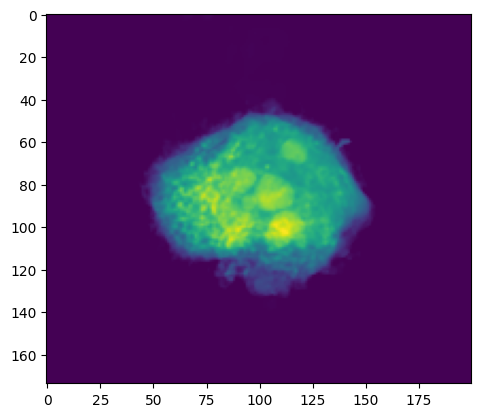

In [70]:
plt.imshow(dRI_GT.transpose(1, 2, 0).sum(axis=-1))

In [71]:
#N = 150


#EM_crop = np.zeros((200, N, N), dtype=np.complex64)
#EM_crop[:] = EM[:, 174//2-N//2:174//2+N//2, 100-N//2:100+N//2]

EM_crop = EM

#dRI_GT_crop = np.zeros((N, N, N), dtype=np.float32)
#dRI_GT_crop[:] = dRI_GT.transpose(1, 2, 0)[174//2-N//2:174//2+N//2,100-N//2:100+N//2]
dRI_GT_crop = dRI_GT.transpose(1, 2, 0)

In [72]:
nx, ny, nz = dRI_GT_crop.shape
print('Crop shape:', EM_crop.shape, dRI_GT_crop.shape)

Crop shape: (220, 174, 200) (174, 200, 150)


In [11]:
dx, dy, dz = 200e-9, 200e-9, 200e-9
kx, ky = torch.meshgrid([torch.fft.fftfreq(nx, d=dx) * 2 * np.pi, torch.fft.fftfreq(ny, d=dy) * 2 * np.pi], indexing='ij')
wavelength = 640e-9
n0 = 1.33
k0 = 2 * np.pi / wavelength
se = (k0 * n0)**2 - kx**2 - ky**2
kz = torch.sqrt(se * (se>0)).cuda()

def forward_model(dRI, q, t, K):

    bs = q.shape[0]
    E = torch.ones((bs, nx, ny), dtype=torch.complex64, device=DEV)
    t_xy = torch.zeros_like(t)
    t_xy[:, :2] = t[:, :2]
    dRI_b = tomographic_model.apply_rotation_batch(dRI, q, t_xy)
    
    for i in range(nz):

        E = torch.fft.ifft2(torch.fft.fft2(E, dim=(1, 2)) * K, dim=(1, 2))
        E = E * torch.exp(1j * dRI_b[...,i] * k0 * dz)

    E = torch.fft.ifft2(torch.fft.fft2(E, dim=(1, 2)) * torch.exp(1j * kz * t[:, None, None, 2] * dz), dim=(1, 2)) 

    return E * torch.exp(-1j*(nz*dz*k0*n0 + t[:, None, None, 2]*dz*k0*n0))

def loss_smooth(q, λ1, λ2):

    qd = torch.diff(q, axis=0)
    qdd = torch.diff(qd, axis=0)
    
    return (λ1 * torch.sum(torch.square(qd)) + λ2 * torch.sum(torch.square(qdd))) / q.shape[0]

def loss_TV(a):

    ax = torch.diff(a, axis=0, append=a[-1, None])
    ay = torch.diff(a, axis=1, append=a[:, -1, None])
    az = torch.diff(a, axis=2, append=a[:, :, -1, None])
    beta = 1e-10
    
    return torch.sqrt(ax**2 + ay**2 + az**2 + beta).sum() / a.numel()
    

def loss_data(E, EM):

    return torch.square(torch.abs(E - EM)).mean()



In [15]:
nz

150

In [16]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# Setup the optics
optics_settings = setup_optics(
        shape=(nx, ny, nz),
        padding_xy=0, 
        microscopy_regime='Brightfield', 
        NA=1.15, 
        wavelength=640e-9, 
        resolution=200e-9, 
        magnification=1, 
        return_field=True)

# Generate the imaging model
brightfield_model = imaging_model(optics_setup=optics_settings)

In [17]:
# Create the tomographic_model
tomographic_model = tomodpdt.Tomography(
    volume_size=(nx, ny, nz), # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='quaternion', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model,
    translation_maxmin=10.0)

In [18]:
from skimage.restoration import unwrap_phase
from scipy.signal import find_peaks

In [19]:
PU = [unwrap_phase(np.angle(E)) for E in EM_crop]

In [20]:
def calc_cc(a, b):
    return np.abs(np.fft.ifft2(np.fft.fft2(a) * np.fft.fft2(b))).max()

In [21]:
cc = []
for i in range(0, 200):
    cc.append(calc_cc(PU[0], PU[i]))
cc = np.array(cc)

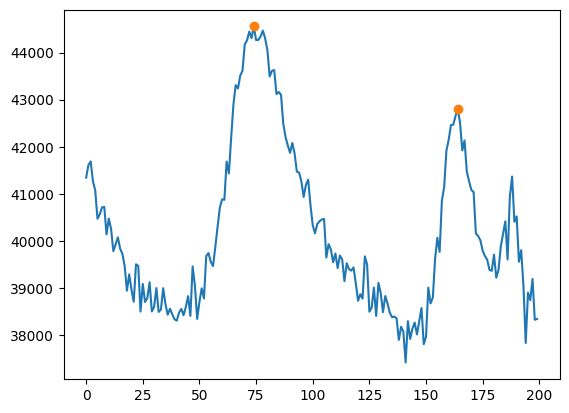

In [22]:
pks = find_peaks(cc, width=10)[0]

plt.plot(cc)
plt.plot(pks, cc[pks], 'o')

In [23]:
pks

array([ 74, 164], dtype=int64)

In [ ]:
asdd

In [ ]:
th = np.array([0.])
for i, pk in enumerate(pks):
    th = np.r_[th, np.linspace(i*np.pi, (i+1)*np.pi, (pks[i] - pks[i-1]) + 1 if i>0 else pks[i])[1:]]
    
th = np.r_[th, np.linspace((i+1)*np.pi, (i+1)*np.pi + np.pi * ((200 - pks[i]) / (pks[i] - pks[i-1])) , 200 - pks[i] + 1)[1:]]

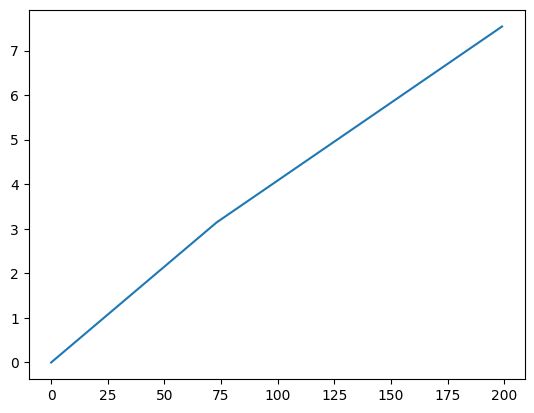

In [25]:
plt.plot(th)

In [26]:
2.3*np.pi

7.225663103256523

In [27]:
Q_GT_new = np.zeros_like(Q_GT)
Q_GT_new[:, 0] = Q_GT[:, 0]
Q_GT_new[:, 1] = -Q_GT[:, 2]
Q_GT_new[:, 2] = -Q_GT[:, 3]
Q_GT_new[:, 3] = -Q_GT[:, 1]

T_GT_new = np.zeros_like(T_GT)
T_GT_new[:, 0] = T_GT[:, 1] / dx
T_GT_new[:, 1] = T_GT[:, 2] / dx
T_GT_new[:, 2] = (T_GT[:, 0] - 150 * dx / 2) / dx

#th = np.linspace(0, 2.3 * np.pi, 200)
Q_start = np.zeros_like(Q_GT_new)
Q_start[:, 0] = np.cos(-th/2)
Q_start[:, 2] = np.sin(-th/2)

T_start = np.zeros_like(T_GT_new)
T_start[:, 2] = - 40.

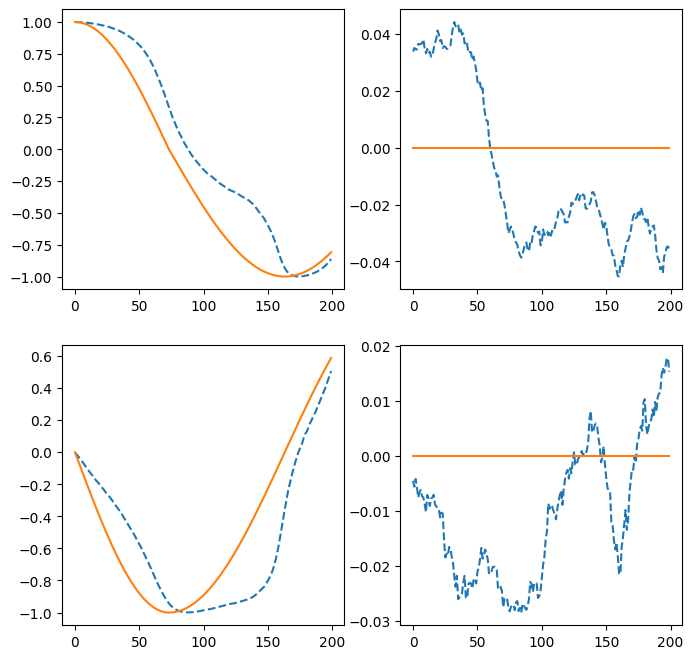

In [28]:
plt.figure(figsize=(8, 8))
for i in range(4):
    plt.subplot(2, 2, i+1) 
    plt.plot(Q_GT_new[:,i], '--')
    plt.plot(Q_start[:,i], '-')

In [30]:
dRI_test.shape

torch.Size([150, 200, 174])

In [31]:
E_test = np.zeros((200, nx, ny), dtype=np.complex64)
bs = 10
K = torch.exp(1j * kz * dz)
dRI_test = torch.Tensor(dRI_GT_crop).to(device=DEV)
Q_test = torch.Tensor(Q_GT_new).to(device=DEV)
T_test = torch.Tensor(T_GT_new).to(device=DEV)

for i in range(200//bs):

    slb = slice(i*bs, (i+1)*bs)
    E_test[slb] = forward_model(dRI_test, Q_test[slb], T_test[slb], K).cpu().numpy()

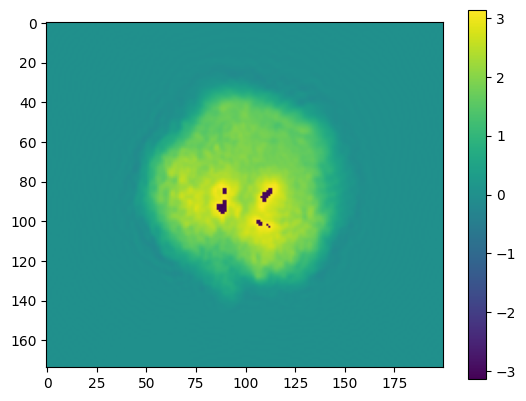

In [32]:
plt.imshow(np.angle(E_test[0]))
plt.colorbar()

In [36]:
maxiter = 250
lr_dRI = 5e-5
lr_q = 3e-6
lr_t = 1e-4
λ_TV = 1e-1
λ1_q = 5e1 
λ2_q = 5e1 

lr_dRI = 5.
lr_q = 1e0
lr_t = 1e3
λ_TV = 7e0
λ1_q = 5e0
λ2_q = 5e0 

#dRI = torch.tensor(dRI_GT_crop, dtype=torch.float32, requires_grad=True, device=DEV)
#Q = torch.tensor(Q_GT_new, requires_grad=True, device=DEV)
#T = torch.tensor(T_GT_new, requires_grad=True, device=DEV)
dRI = torch.zeros((nx, ny, nz), dtype=torch.float32, requires_grad=True, device=DEV)

Q = torch.tensor(Q_start, dtype=torch.float32, requires_grad=True, device=DEV)
T = torch.tensor(T_start, dtype=torch.float32, requires_grad=True, device=DEV)

EM_trch = torch.tensor(EM_crop * np.exp(-1j * np.angle(EM_crop[:, :20, :20]).mean(axis=(1,2), keepdims=True)), requires_grad=False, device=DEV) 
errors = []

In [37]:
1e-1 * dRI.numel()

522000.0

In [38]:
i = 0
idx = np.random.permutation(200)
idx_b = idx[i * bs: (i+1) * bs]
Eb = forward_model(dRI, Q[idx_b], T[idx_b], K)
err_loc = loss_data(Eb, EM_trch[idx_b]) + λ_TV * loss_TV(dRI) + loss_smooth(Q, λ1_q, λ2_q)
err_loc.backward()
loss_data(Eb, EM_trch[idx_b]), λ_TV * loss_TV(dRI), loss_smooth(Q, λ1_q, λ2_q)

(tensor(0.5507, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(7.0000e-05, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(0.0018, device='cuda:0', grad_fn=<DivBackward0>))

In [52]:
for it in range(maxiter):

    idx = np.random.permutation(200)
    err = 0
    
    for i in range(200//bs):
            
        idx_b = idx[i * bs: (i+1) * bs]
        Eb = forward_model(dRI, Q[idx_b], T[idx_b], K)
        err_loc = loss_data(Eb, EM_trch[idx_b]) + λ_TV * loss_TV(dRI) + loss_smooth(Q, λ1_q, λ2_q)
        err_loc.backward()
        err += err_loc.item()
        #err_q = loss_smooth(Q, λ1_q, λ2_q)
        #err_q.backward()
        #err += err_q
        #err += err_loc

        with torch.no_grad():

            torch.clip(dRI - lr_dRI * dRI.grad, 0., 1., out=dRI)
            
            Q -= lr_q * Q.grad
            Q[:] = Q / torch.norm(Q, dim=1, keepdim=True)
            T -= lr_t * T.grad
            
            #print(torch.abs(dRI.grad).mean(), torch.abs(Q.grad).mean(), torch.abs(T.grad[:, :2]).mean(), torch.abs(T.grad[:, 2]).mean())

            dRI.grad = None
            Q.grad = None
            T.grad = None
     
        

    #err_q = λ_q * loss_smooth(Q)
    #err_q.backward()
    #err += err_q
    
    #with torch.no_grad():

    #    Q -= lr_q * Q.grad
    #    Q[:] = Q / torch.norm(Q, dim=1, keepdim=True)
    #    T -= lr_t * T.grad
        
    #    print(torch.abs(Q.grad).mean(), torch.abs(T.grad[:, :2]).mean(), torch.abs(T.grad[:, 2]).mean())

    #    Q.grad = None
    #    T.grad = None
    
    print(it, err)
    errors.append(err)
    

    

        
#432509.2500

0 0.8999027237296104
1 0.8993780426681042
2 0.8988728187978268
3 0.8985651694238186
4 0.8979308046400547
5 0.8974738493561745
6 0.8971091397106647
7 0.8965738005936146
8 0.8961760029196739
9 0.8957387208938599
10 0.8952424302697182
11 0.8948273472487926
12 0.8944030441343784
13 0.8939826115965843
14 0.8934554718434811
15 0.8930630125105381
16 0.8925789929926395
17 0.8921972624957561
18 0.8917487636208534
19 0.8912388645112514
20 0.8908789567649364
21 0.890478327870369
22 0.8900993540883064
23 0.8895837217569351
24 0.8891952708363533
25 0.8888781778514385
26 0.8883532956242561
27 0.8879922144114971
28 0.8876380994915962
29 0.8871573582291603
30 0.8868694566190243
31 0.8864453360438347
32 0.8860212787985802
33 0.8857556656002998
34 0.8852190189063549
35 0.884902149438858
36 0.8845727108418941
37 0.8841032795608044
38 0.8837339915335178
39 0.8833425641059875
40 0.8830500319600105
41 0.8826386108994484
42 0.8822642676532269
43 0.8819538652896881
44 0.8815143033862114
45 0.8812124133110046


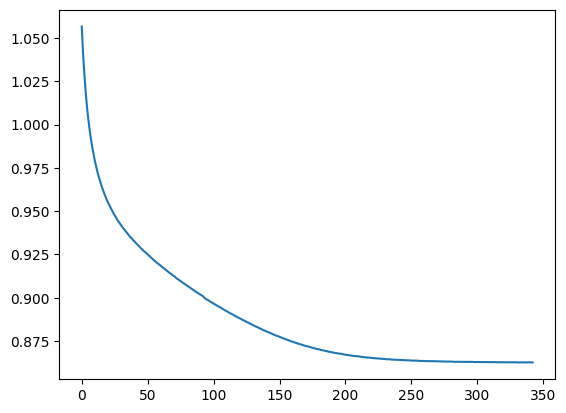

In [53]:
plt.plot(errors[10:])

In [54]:
#import stackview
#stackview.curtain(dRI.cpu().detach().numpy(), dRI_GT_crop)

In [61]:
xs, ys, zs = dRI.shape

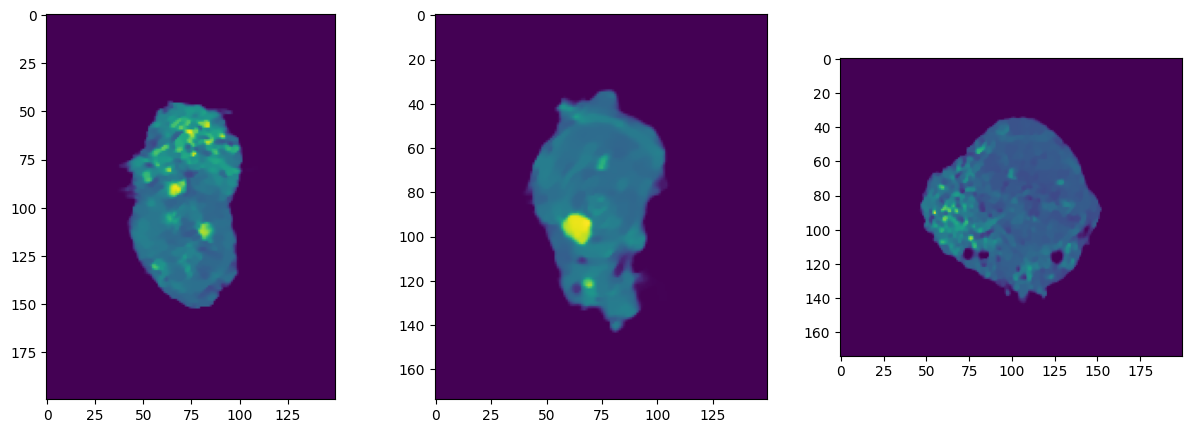

In [62]:
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dRI.cpu().detach().numpy()[xs//2])

plt.subplot(132)
plt.imshow(dRI.cpu().detach().numpy()[:, ys//2])

plt.subplot(133)
plt.imshow(dRI.cpu().detach().numpy()[:, :, zs//2])


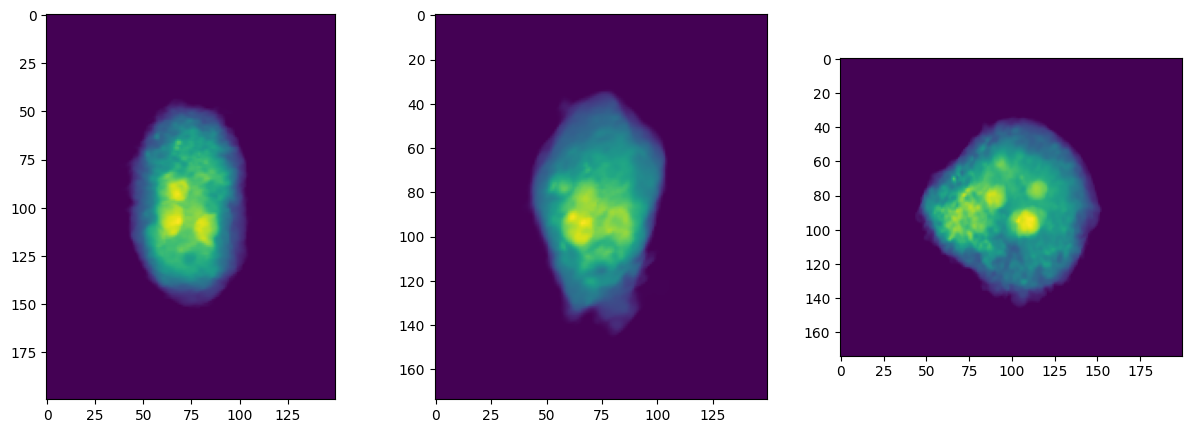

In [63]:
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=0))

plt.subplot(132)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=1))

plt.subplot(133)
plt.imshow(dRI.cpu().detach().numpy().sum(axis=2))


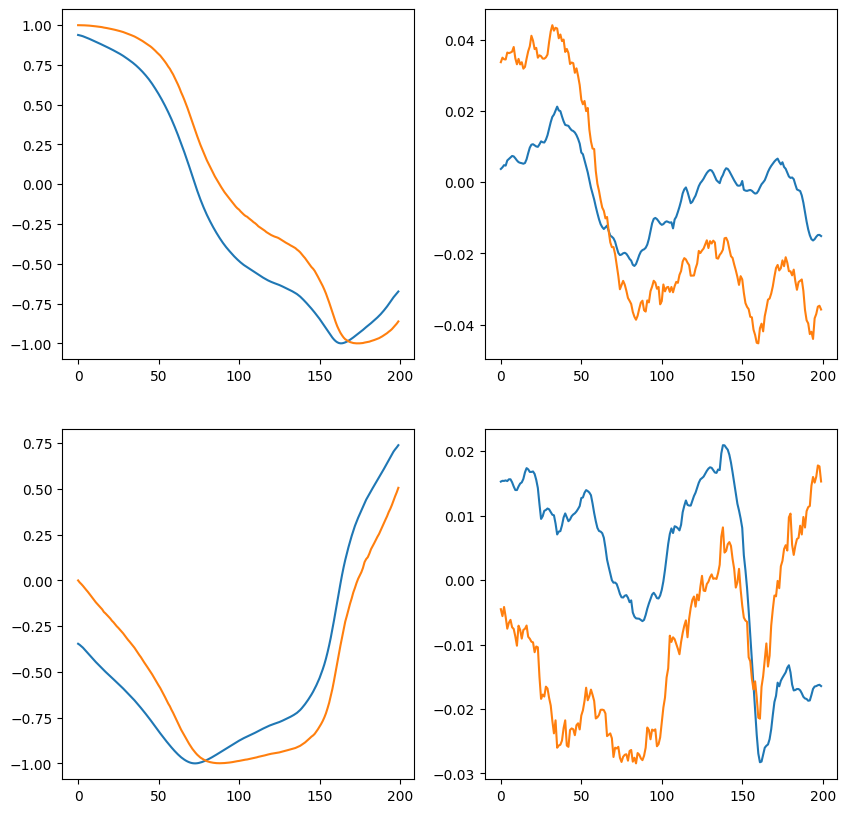

In [64]:
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(2, 2, 1+i)
    plt.plot(Q.cpu().detach().numpy()[:, i])
    plt.plot(Q_GT_new[:, i])

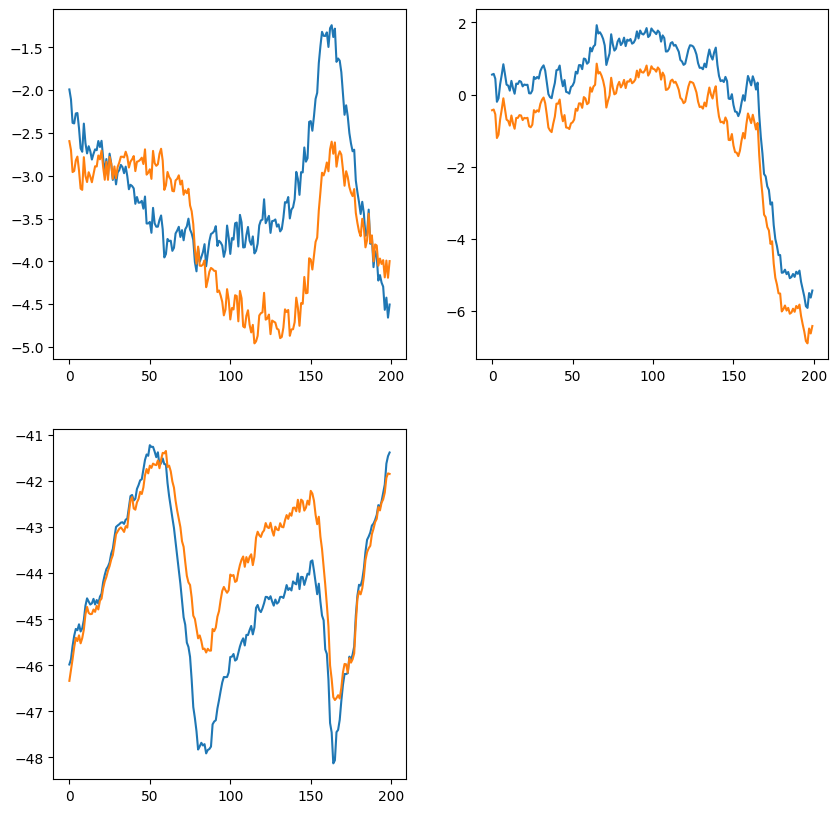

In [65]:
plt.figure(figsize=(10, 10))
for i in range(3):
    plt.subplot(2, 2, 1+i)
    plt.plot(T.cpu().detach().numpy()[:,i])
    plt.plot(T_GT_new[:,i])



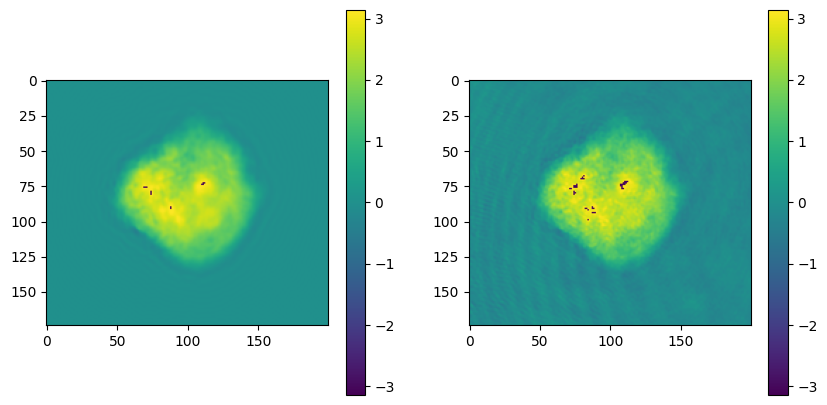

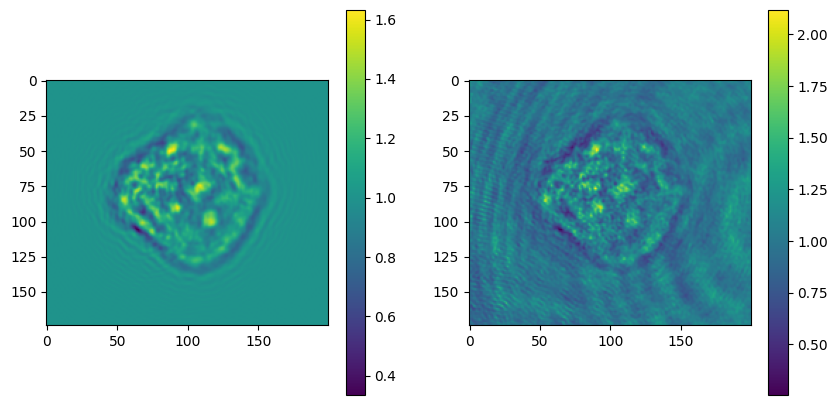

In [66]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(np.angle(Eb.cpu().detach().numpy()[0]))
plt.colorbar()
plt.subplot(122)
plt.imshow(np.angle(EM_trch.cpu().detach().numpy()[idx_b][0]))
plt.colorbar()

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(np.abs(Eb.cpu().detach().numpy()[0]))
plt.colorbar()
plt.subplot(122)
plt.imshow(np.abs(EM_trch.cpu().detach().numpy()[idx_b][0]))
plt.colorbar()